# Ch10. 검증 및 튜닝

[10.1] 학습 지표
- 하이퍼파라미터: 학습 전에 설정하는 매개 변수 값
- 좋은 하이퍼파라미터 선택 -> 머신러닝 모델의 성능을 평가하는 지표를 정의하는 것이 필수적

[10.1.1] 회귀 분석
- $L^1$ 및 $L^2$ 노름으로 평가
1. $\text{MAE}(\textbf{y},\tilde{\textbf{y}})&=\frac{1}{I}\sum_{i=1}^I|y_i-\tilde{y}_i|$
2. $\text{MSE}(\textbf{y},\tilde{\textbf{y}})&=\frac{1}{I}\sum_{i=1}^I(y_i-\tilde{y}_i)^2$ 의 제곱 -> RMSE
3. $R^2(\textbf{y},\tilde{\textbf{y}})=1- \frac{\sum_{i=1}^I(y_i-\tilde{y}_i)^2}{\sum_{i=1}^I(y_i-\bar{y})^2}$
- 분모에서 $\bar{y}$ 제거: 0 예측과 비교 & $R^2$ 감소 ~ 지표가 보수적으로 변함
4. 원래의 값에 대한 상대적인 오차 ~ 오차는 백분율 점수로 표시됨
- $\text{MAPE}(\textbf{y},\tilde{\textbf{y}})&=\frac{1}{I}\sum_{i=1}^I\left|\frac{y_i-\tilde{y}_i}{y_i}\right|$
- $\text{MSPE}(\textbf{y},\tilde{\textbf{y}})&=\frac{1}{I}\sum_{i=1}^I\left(\frac{y_i-\tilde{y}_i}{y_i}\right)^2$
- $\text{RMSLE}(\textbf{y},\tilde{\textbf{y}})=\sqrt{\frac{1}{I}\sum_{i=1}^I\log\left(\frac{1+y_i}{1+\tilde{y}_i}\right)}$

(\*) MSE:
1. 실현 수익률의 제곱합
2. 예측 수익률의 제곱합: 예측값의 0 주위 분산 제어
- 모델 값의 분산
3. 이 둘의 곱: 중요 but 알고리듬은 이 지표와 관련해 최적화를 하지 않음
- 증가시킴으로써 MSE 감소 효과 ~ 방향 일치

[10.1.2] 분류 분석
참: 양의 수익률 or 벤치마크보다 높은 수익률(1)
거짓: 그 반대(0)
- 참 양성: $TP=I^{-1}\sum_{i=1}^I1_{\{y_i=\tilde{y}_i=1 \}}$
- 참 음성: $TN=I^{-1}\sum_{i=1}^I1_{\{y_i=\tilde{y}_i=0 \}}$
- 거짓 양성: $FP=I^{-1}\sum_{i=1}^I1_{\{y_i=0,\ \tilde{y}_i=1 \}}$
- 거짓 음성: $FN=I^{-1}\sum_{i=1}^I1_{\{y_i=1,\ \tilde{y}_i=0 \}}$
$\\ \rarr$ 네 숫자의 합은 0

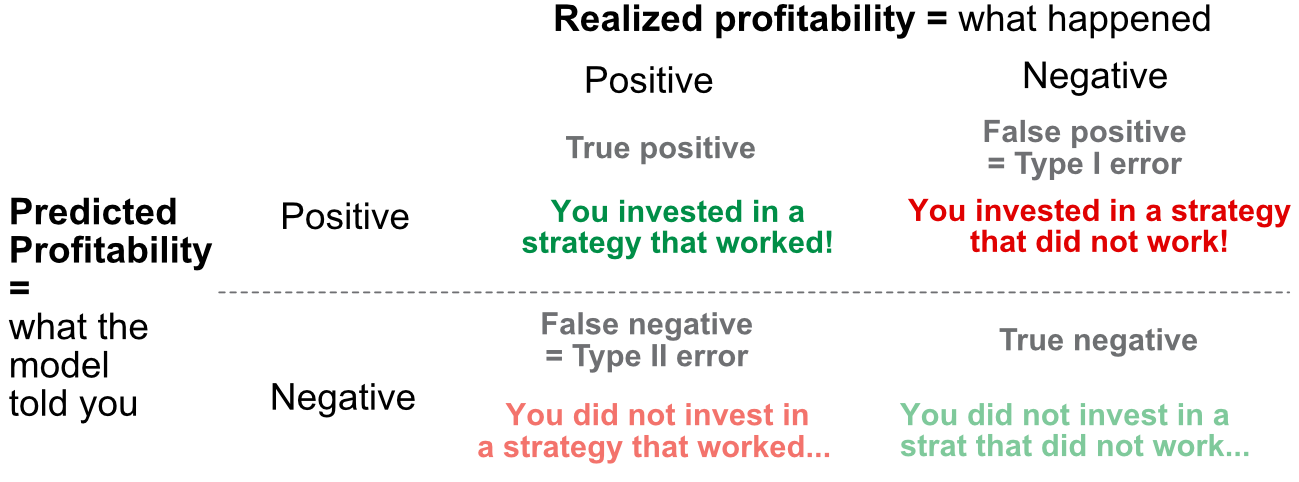

(\*) AUC
$\\$: ROC 곡선 아래의 영역
- 분류기: 한 인스턴스가 한 클래스에 속할 확률인 출력을 생성 -> 가장 높은 값을 가진 클래스를 선택하며 변환됨
- ROC: 결정 임계치가 바뀌면 어떻게 되는지 테스트 ~ 임계치가 0에서 1로 증가했을 떄 위양성률의 함수로 재현율 그림
- 재현율: TP/(TP+FN) ~ 참인 자산을 감지하는 능력
- 위양성률: FP/(FP+TN) ~ 거짓인 자산을 참으로 잘못 예측
- ROC 곡선이 45도 이상인 알고리듬은 평균적인 분류기보다 더 나은 성능을 발휘함

In [ ]:
import import_ipynb
from Ch1 import data_ml, features_short, idx_train, idx_test
training_sample=data_ml[data_ml.index.isin(idx_train)]
testing_sample=data_ml[data_ml.index.isin(idx_test)]

: 

In [ ]:
'''
from sklearn.metrics import roc_curve, RocCurveDisplay, auc
fpr, tpr, thresholds=roc_curve(testing_sample['R1M_Usd_C'].values, fit_RF_C.predict(testing_sample[features]))
roc_auc=auc(fpr, tpr)
display=RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='example estimator')
display.plot()
plt.show()
'''

- 전체 곡선 정보: 곡선 아래 영역 ~ 해당 함수의 적분으로 합성됨
$\\ \therefore$ 좋은 모델: AUC가 0.5 이상 => 완벽한 모델: AUC가 1임

[10.2] 검증
- 검증: 실제 or 라이브 데이터를 배포하기 전에 모델을 테스트하고 조정하는 단계
[10.2.1] 분산-편향 트레이트 오프 ~ 지도 학습의 핵심
$\\$ If 데이터 생성 by 
$\\ y_i=f(\textbf{x}_i)+\epsilon_i, \quad   \mathbb{E}[\boldsymbol{\epsilon}]=0, \quad \mathbb{V}[\boldsymbol{\epsilon}]=\sigma^2$
- MSE: $\mathbb{E}[\hat{\epsilon}^2]=\underbrace{\mathbb{V}[\hat{f}(\textbf{x})]}_{\text{variance of model}}+ \quad \underbrace{\mathbb{E}[(f(\textbf{x})-\hat{f}(\textbf{x}))]^2}_{\text{squared bias}}\quad +\quad\sigma^2 \nonumber$

마지막 구성 요소: 모델 변경에 영향을 받지 않음 -> 두 구성 요소의 합을 최소화하는 것이 과제임

[10.2.4] 과최적화의 위험: Solution
1. 모델의 복잡성 줄이기
- 모델의 복잡성: 모델의 매개 변수 개수 & 그 크기를 통해 근사됨
2. 회귀: (1) 매개 변수 개수 (2) 라쏘, 릿지, 엘라스틱넷을 통한 페널티 적용
3. 트리 기반: (1) 잎사귀 개수 제한(by 최대 깊이, 최소 인스턴스 개수 등..)
4. 랜덤 포레스트: 트리 개수 제어 가능, 하위 샘플 크기 및 학습을 위해 유지하는 특성의 개수
5. 부스트 트리: 학습 속도(각 new 트리의 영향을 할인)
6. 신경망: 학습 속도, 가중치 및 편향에 대한 패널티(with 노름), 드롭아웃

[10.3] 하이퍼파라미터 찾기
$\\$ If there are 'q' 매개 변수 ~ 모델 실행 전 정의해야 함
- 매개 변수의 다양한 값을 테스트해 가장 좋은 결과를 산출하는 값을 선택함
- 독립적 테스트: 격자(결정론적) 탐색 & 무작위 탐색
- 베이지안 최적화: 
$\\ \textbf{p}_*=\underset{\textbf{p}}{\text{argmin}} \ O(\textbf{p})$
- $\ O$: 페널티 및 제약 조건과 결합된 손실 함수
- $\textbf{p}$: 하이퍼파라미터 벡터
- 목표: 입력과 출력 간 베이지안 선형 회귀 구축

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer, mean_absolute_error
scorer=make_scorer(mean_absolute_error)
params={
    'learning_rate':[0.1,0.3,0.5,0.7,0.9],
    'n_estimators':[10,50,100],
    'reg_lambda':[0.01,0.1,1,10,100]
}

In [4]:
import import_ipynb
from Ch1 import data_ml, features, idx_train, idx_test
training_sample=data_ml[data_ml.index.isin(idx_train)]
testing_sample=data_ml[data_ml.index.isin(idx_test)]

y_train=training_sample['R1M_Usd'].values
X_train=training_sample[features].values

In [6]:
import xgboost as xgb
import pandas as pd
model=xgb.XGBRegressor(max_depth=3, n_jobs=-1, objective='reg:squarederror')
model_gs=GridSearchCV(model, param_grid=params, cv=2, scoring='neg_mean_squared_error')
model_gs.fit(X_train, y_train)
cv_results=pd.DataFrame(model_gs.cv_results_)
print(f'Best Parameters using grid search: {model_gs.best_params_}')

Best Parameters using grid search: {'learning_rate': 0.1, 'n_estimators': 10, 'reg_lambda': 100}


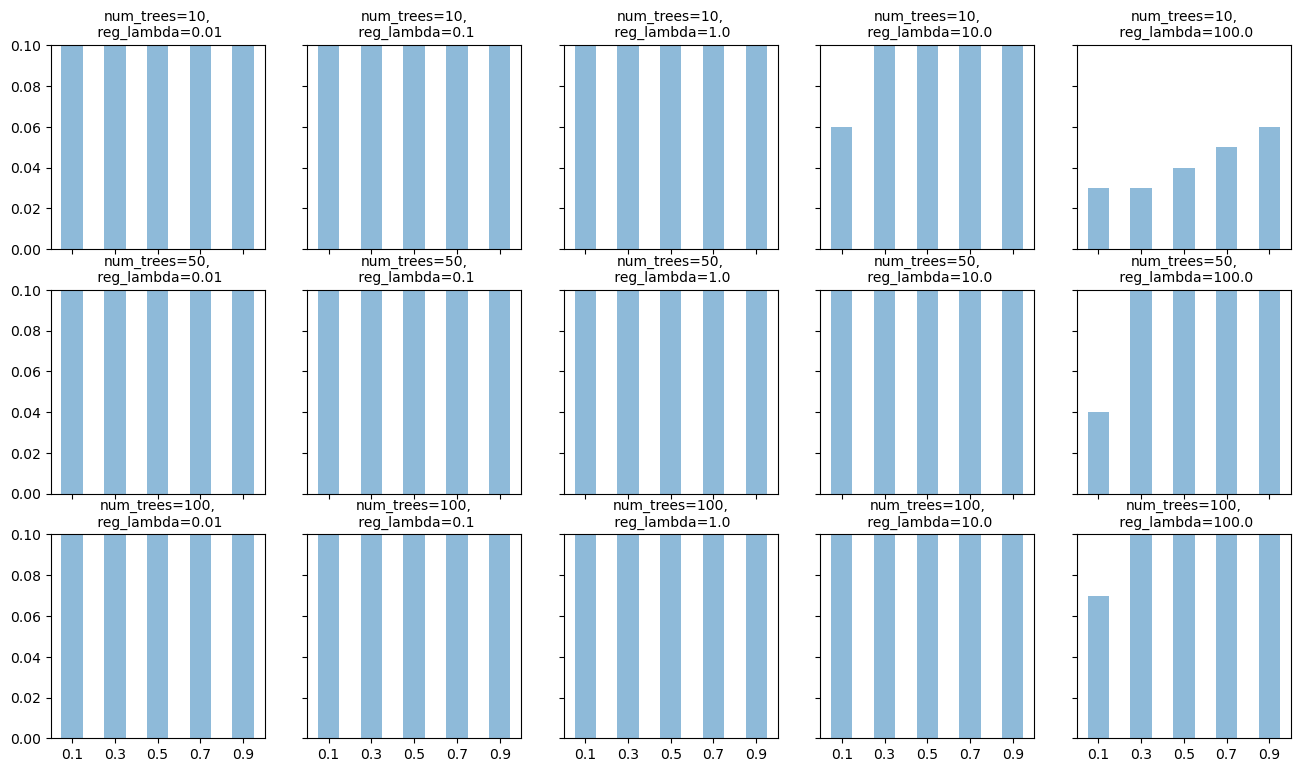

In [7]:
import matplotlib.pyplot as plt
import numpy as np
res_df=pd.DataFrame(cv_results, columns=['param_n_estimators','param_learning_rate','param_reg_lambda','mean_test_score'])
res_df['mean_test_score']=-res_df['mean_test_score'].values # 모든 오차 양수로 가정
fig, axes=plt.subplots(figsize=(16,9),nrows=3,ncols=5)
ax_all=plt.gca()
cnt=0
for param, tmp in res_df.groupby(['param_n_estimators','param_reg_lambda']):
    ax=axes[cnt//5][cnt%5]
    np.round(
        tmp[['param_learning_rate','mean_test_score']],2
    ).plot.bar(ax=ax, x='param_learning_rate', y='mean_test_score', alpha=0.5, legend=None)
    ax.set_xlabel("")
    ax.set_ylim(0,0.1) # y 범위 지정
    if cnt//5 < 2:
        ax.xaxis.set_ticklabels("")
    else:
        for label in ax.get_xticklabels():
            label.set_rotation(0)
    if cnt%5>0:
        ax.yaxis.set_ticklabels("")
    ax.set_title(f'num_trees={param[0]},\n reg_lambda={param[1]}', fontsize=10)
    cnt=cnt+1

In [ ]:
!pip install skopt

In [ ]:
# 베이지안 최적화
'''
from skopt import BayesSearchCV
search_spaces=params
opt=BayesSearchCV(estimator=model, search_spaces=search_spaces, scoring='neg_mean_squared_error', cv=2)
opt.fit(X_train, y_train)
cv_results_opt=pd.DataFrame(opt.cv_results_)
print(f'Best Parameters using bayes opt: {opt.best_params}')
'''